In [10]:
import sys, os
sys.path.append(os.path.abspath(".."))
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from preprocessing.preprocessing_utils import nn_preprocess
from sklearn.model_selection import train_test_split

In [11]:

# EVALUATION METRICS

def d_squared_poisson(y_true, y_pred, w):
    """Calculates D^2  and prints the Model Deviance and Null Deviance explicitly."""
    #  Deviance of the model
    dev_model = manual_mean_poisson_deviance(y_true, y_pred, sample_weight=w)
    
    # Intercept only
    mu = np.average(y_true, weights=w)
    y_null = np.full_like(y_true, mu)
    dev_null = manual_mean_poisson_deviance(y_true, y_null, sample_weight=w)
    
    # D^2
    d2 = 1 - (dev_model / dev_null)
    
    print(f"D^2 Calculation")
    print(f"Null Deviance (Baseline): {dev_null:.5f}")
    print(f"Model Deviance:           {dev_model:.5f}")
    print(f"D^2 Score:                {d2:.2%}")
    print(f"-----------------------")
    
    return d2

def manual_mean_poisson_deviance(y_true, y_pred, sample_weight=None):
    if sample_weight is None:
        sample_weight = np.ones_like(y_true)
    
    y_pred = np.clip(y_pred, 1e-10, None) 
    
    # Deviance formula, first term in formula 
    term1 = np.zeros_like(y_true)
    mask = y_true > 0
    term1[mask] = y_true[mask] * np.log(y_true[mask] / y_pred[mask])
    
    # second term of formula 
    term2 = -(y_true - y_pred)
    
    deviance = 2 * sample_weight * (term1 + term2)
    return np.sum(deviance) / np.sum(sample_weight)

        
def plot_lorenz_curve(y_true, y_pred, w, title="Lorenz Curve"):
    """Gini coefficient visualization,  prints AUC and Gini values."""
    # Sort by predicted risk
    data = pd.DataFrame({
    'True': y_true.flatten(), 
    'Pred': y_pred.flatten(), 
    'Weight': w.flatten()
})
    data = data.sort_values('Pred')
    
    # Cumulative distributions
    data['CumExposure'] = data['Weight'].cumsum() / data['Weight'].sum()
    data['CumClaims'] = (data['True'] * data['Weight']).cumsum() / (data['True'] * data['Weight']).sum()
    
    # Gini Calculation
    auc = np.trapz(data['CumClaims'], data['CumExposure'])
    gini = 1 - 2 * auc 
    
    
    print(f"Gini Calculation")
    print(f"AUC: {auc:.5f}")
    print(f"Gini :{gini:.5f}")
    print(f"---------------")
    
   
    plt.figure(figsize=(6, 6))
    plt.plot(data['CumExposure'], data['CumClaims'], label=f'Model (Gini: {gini:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random (Gini: 0.0)')
    plt.xlabel('Cumulative Exposure (sorted by Pred Risk)')
    plt.ylabel('Cumulative Actual Claims')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return gini

def plot_calibration(y_true, y_pred, w, n_bins=10, title="Calibration Plot"):
    """ Splits the data into risk bins, compares Average Predicted Risk vs Average Actual Risk.Prints values"""
    data = pd.DataFrame({
    'True': y_true.flatten(), 
    'Pred': y_pred.flatten(), 
    'Weight': w.flatten()
})
    
    try:
        data['Bin'] = pd.qcut(data['Pred'], n_bins, duplicates='drop')
    except:
        data['Bin'] = pd.cut(data['Pred'], n_bins)
        
    grouped = data.groupby('Bin', observed=False).apply(
        lambda x: pd.Series({
            'AvgPred': np.average(x['Pred'], weights=x['Weight']),
            'AvgTrue': np.average(x['True'], weights=x['Weight']),
            'Exposure': x['Weight'].sum(),
            'Count': len(x)
        })
    )
    
   
    print(f"\n---{title} Data ---")
    
    print_df = grouped.copy()
    print_df['Diff'] = print_df['AvgPred'] - print_df['AvgTrue']
    print_df['Error %'] = (print_df['Diff'] / print_df['AvgTrue']) * 100
    
    
    print(print_df[['AvgPred', 'AvgTrue', 'Diff', 'Exposure']].to_string(float_format="%.4f"))
    print("------------------------------------------------\n")
    
    
   
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(grouped))
    width = 0.35
    
    ax1.bar(x - width/2, grouped['AvgPred'], width, label='Predicted Rate', alpha=0.8, color='teal')
    ax1.bar(x + width/2, grouped['AvgTrue'], width, label='Actual Rate', alpha=0.7, color='slategrey')
    
    ax1.set_xlabel('Risk Groups (Low -> High)')
    ax1.set_ylabel('Claim Rate')
    ax1.set_title(title)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{i+1}" for i in x])
    ax1.legend(loc='upper left')
    
    ax2 = ax1.twinx()
    ax2.plot(x, grouped['Exposure'], color='red', linestyle='--', marker='o', label='Exposure Vol', alpha=0.3)
    ax2.set_ylabel('Total Exposure (Years)')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names, title="Feature Importance"):
    """Visualizes and prints which features are most important for DT. """
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    print(f"\n--- {title} Scores ---")
    print(f"{'Rank':<5} {'Feature':<20} {'Importance':<10}")
    print("-" * 40)
    
    # Print top 15 features or all if fewer
    top_n = min(15, len(feature_names))
    for i in range(top_n):
        idx = indices[i]
        print(f"{i+1:<5} {feature_names[idx]:<20} {importances[idx]:.5f}")
    print("-------------------------------\n")
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.bar(range(len(importances)), importances[indices], align="center")
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.xlabel("Feature")
    plt.ylabel("Importance Score")
    plt.tight_layout()
    plt.show()

In [12]:
# Load Data
print("Loading data...")
train_full = pd.read_csv("../data/claims_train.csv")
test_raw = pd.read_csv("../data/claims_test.csv")


train_subset, val_subset = train_test_split(train_full, test_size=0.2, random_state=42)


X_train_df, y_train, w_train, scaler = nn_preprocess(train_subset, scaler=None)
train_cols = X_train_df.columns.tolist()

X_val_df, y_val, w_val, _ = nn_preprocess(val_subset, scaler=scaler, ref_columns=train_cols)
X_test_df, y_test, w_test, _ = nn_preprocess(test_raw, scaler=scaler, ref_columns=train_cols)

X_train = X_train_df.values.astype(np.float32)
y_train = y_train.values.astype(np.float32).reshape(-1, 1)
w_train = w_train.values.astype(np.float32).reshape(-1, 1)

X_val = X_val_df.values.astype(np.float32)
y_val = y_val.values.astype(np.float32).reshape(-1, 1)
w_val = w_val.values.astype(np.float32).reshape(-1, 1)

X_test = X_test_df.values.astype(np.float32)
y_test = y_test.values.astype(np.float32).reshape(-1, 1)
w_test = w_test.values.astype(np.float32).reshape(-1, 1)

print(f"Data Loaded. Features: {X_train.shape[1]}")

Loading data...
Data Loaded. Features: 124


In [13]:
class ManualNN:
    def __init__(self, input_dim, hidden_layers, dropout_rate=0.0):
        """
        Initializes weights using He Initialization.
        """
        self.layers = []
        self.params = {}
        self.grads = {}
        self.cache = {}
        self.dropout_rate = dropout_rate
        self.training = True
        
        layer_dims = [input_dim] + hidden_layers + [1]
        
        for i in range(1, len(layer_dims)):
            scale = np.sqrt(2.0 / layer_dims[i-1])
            self.params[f'W{i}'] = np.random.randn(layer_dims[i-1], layer_dims[i]) * scale
            self.params[f'b{i}'] = np.zeros((1, layer_dims[i]))
            
        self.num_layers = len(layer_dims) - 1


        self.m = {}
        self.v = {}
        for key in self.params:
            self.m[key] = np.zeros_like(self.params[key])
            self.v[key] = np.zeros_like(self.params[key])
        self.t = 0

    def forward(self, X):
        A = X
        self.cache['A0'] = X
        
        for i in range(1, self.num_layers):
            W = self.params[f'W{i}']
            b = self.params[f'b{i}']
            
            Z = np.dot(A, W) + b
            self.cache[f'Z{i}'] = Z
            
            A = np.maximum(0, Z)
            
            if self.training and self.dropout_rate > 0:
                mask = (np.random.rand(*A.shape) > self.dropout_rate) / (1.0 - self.dropout_rate)
                A = A * mask
                self.cache[f'mask{i}'] = mask
            
            self.cache[f'A{i}'] = A
            
        W_last = self.params[f'W{self.num_layers}']
        b_last = self.params[f'b{self.num_layers}']
        
        Z_last = np.dot(A, W_last) + b_last
        self.cache[f'Z{self.num_layers}'] = Z_last
        
        A_last = np.exp(Z_last)
        self.cache[f'A{self.num_layers}'] = A_last
        
        return A_last

    def backward(self, y_true, w_expo):

        m = y_true.shape[0]
        L = self.num_layers
        A_last = self.cache[f'A{L}']
        
        w_sum = np.sum(w_expo) + 1e-12
        dZ = 2.0 * w_expo * (A_last - y_true) / w_sum
        
        self.grads[f'dW{L}'] = np.dot(self.cache[f'A{L-1}'].T, dZ) 
        self.grads[f'db{L}'] = np.sum(dZ, axis=0, keepdims=True)
        
        for i in range(L-1, 0, -1):
            dA = np.dot(dZ, self.params[f'W{i+1}'].T)
            
            if self.training and self.dropout_rate > 0:
                dA = dA * self.cache[f'mask{i}']
            
            Z = self.cache[f'Z{i}']
            dZ = dA * (Z > 0)
            
            prev_A = self.cache[f'A{i-1}']
            self.grads[f'dW{i}'] = np.dot(prev_A.T, dZ) 
            self.grads[f'db{i}'] = np.sum(dZ, axis=0, keepdims=True)

    def adam_W(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, weight_decay=0.0
    ):
        self.t += 1

        for key in self.params:
            grad = self.grads[f'd{key}']


            self.m[key] = beta1 * self.m[key] + (1 - beta1) * grad
            self.v[key] = beta2 * self.v[key] + (1 - beta2) * (grad ** 2)

            m_hat = self.m[key] / (1 - beta1 ** self.t)
            v_hat = self.v[key] / (1 - beta2 ** self.t)


            self.params[key] -= lr * m_hat / (np.sqrt(v_hat) + epsilon)


            if weight_decay > 0:
                self.params[key] -= lr * weight_decay * self.params[key]
                

    def train_mode(self):
        self.training = True
        
    def eval_mode(self):
        self.training = False

In [14]:
def train_manual_model(config, lr, weight_decay, epochs=500, batch_size=1024):
    input_dim = X_train.shape[1]

    model = ManualNN(input_dim, config, dropout_rate=0.2)
    
    n_samples = X_train.shape[0]
    
    best_val_loss = float('inf')
    best_params = None
    patience = 15
    counter = 0
    history = []
    
    print(f"Training Manual NN {config} | LR: {lr} | weight_decay: {weight_decay}")
    
    for epoch in range(epochs):
        epoch_num=0.0
        epoch_den = 0.0
        
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        w_shuffled = w_train[indices]
        
        model.train_mode()
        
        for i in range(0, n_samples, batch_size):
            end = min(i + batch_size, n_samples)

            X_batch = X_shuffled[i:end]
            y_batch = y_shuffled[i:end]
            w_batch = w_shuffled[i:end]

            y_pred_batch = model.forward(X_batch)
            y_pred_batch_clip = np.clip(y_pred_batch, 1e-10, None)

            term1 = np.zeros_like(y_batch)
            mask = y_batch > 0
            term1[mask] = y_batch[mask] * np.log(y_batch[mask] / y_pred_batch_clip[mask])

            dev_i = 2.0 * (term1 - (y_batch - y_pred_batch_clip))
            epoch_num += np.sum(w_batch * dev_i)
            epoch_den += np.sum(w_batch)

            model.backward(y_batch, w_batch)
            model.adam_W(lr=lr, weight_decay=weight_decay)
            
        avg_train_loss = epoch_num / (epoch_den + 1e-12)
        history.append(avg_train_loss)     

        model.eval_mode()
        val_pred = model.forward(X_val)
        val_loss = manual_mean_poisson_deviance(y_val, val_pred, w_val)
        
        
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            best_params = copy.deepcopy(model.params)
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
                
        if (epoch+1) % 10 == 0:
            print(f"   Epoch {epoch+1}: Val Loss {val_loss:.5f}")
            
    if best_params is not None:
        model.params = best_params
        
    return model, best_val_loss, history

In [15]:
winner_arch = [128, 64] 
learning_rate = 0.0005
weight_decay = 0.01

manual_model, final_val_loss, loss_history = train_manual_model(
    winner_arch, learning_rate, weight_decay, epochs=100
)

manual_model.eval_mode()
test_preds = manual_model.forward(X_test)




Training Manual NN [128, 64] | LR: 0.0005 | weight_decay: 0.01
   Epoch 10: Val Loss 0.59210
   Epoch 20: Val Loss 0.59174
   Epoch 30: Val Loss 0.59035
Early stopping triggered at epoch 38


Architecture:   [128, 64]


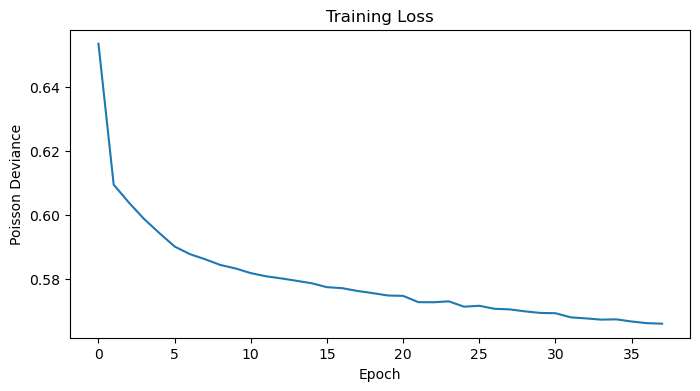

D^2 Calculation
Null Deviance (Baseline): 0.63304
Model Deviance:           0.58607
D^2 Score:                7.42%
-----------------------
Gini Calculation
AUC: 0.33991
Gini :0.32018
---------------


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7128\2202715360.py:57: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(data['CumClaims'], data['CumExposure'])


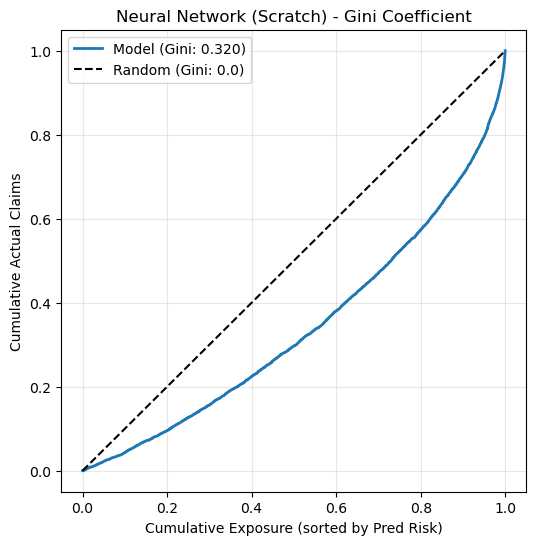

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7128\2202715360.py:92: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = data.groupby('Bin', observed=False).apply(



---Calibration Plot Data ---
                    AvgPred  AvgTrue    Diff  Exposure
Bin                                                   
(-0.0009511, 0.05]   0.0391   0.0460 -0.0069 8210.5635
(0.05, 0.0612]       0.0559   0.0544  0.0014 7879.4756
(0.0612, 0.0706]     0.0660   0.0638  0.0022 7727.4424
(0.0706, 0.0796]     0.0751   0.0710  0.0040 7772.9893
(0.0796, 0.0892]     0.0843   0.0768  0.0075 7695.4111
(0.0892, 0.1]        0.0946   0.0903  0.0043 7639.0840
(0.1, 0.116]         0.1075   0.1002  0.0073 7312.2559
(0.116, 0.143]       0.1274   0.1154  0.0121 6648.8979
(0.143, 0.203]       0.1676   0.1546  0.0129 5878.5146
(0.203, 2.794]       0.3713   0.3591  0.0122 4862.2305
------------------------------------------------



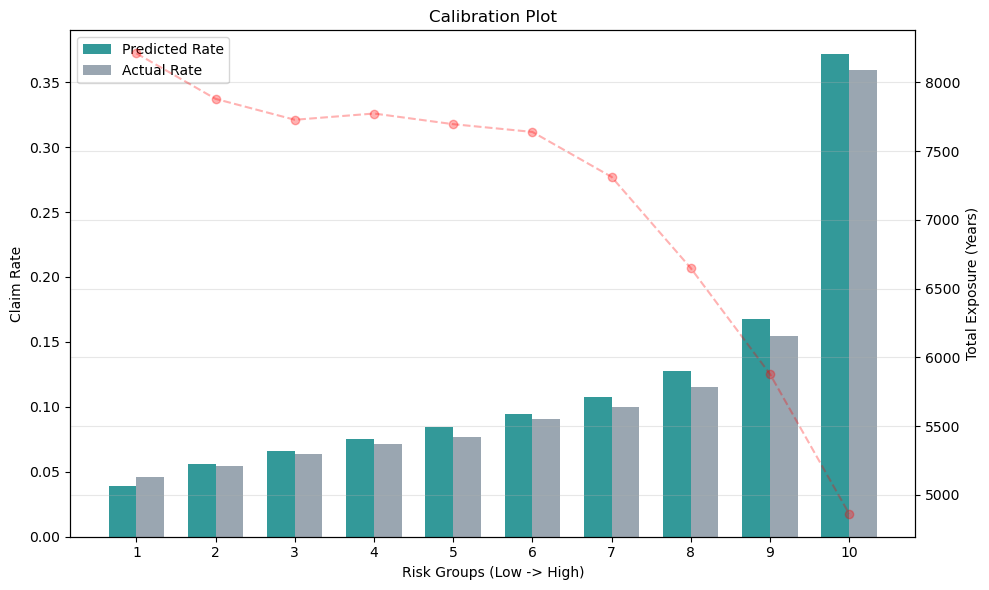

In [16]:

print(f"Architecture:   {winner_arch}")

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Poisson Deviance")
plt.show()


# Metrics
test_deviance = manual_mean_poisson_deviance(y_test, test_preds, sample_weight=w_test)
d2 = d_squared_poisson(y_test, test_preds, w_test)

# Gini Plot
plot_lorenz_curve(y_test, test_preds, w_test, title="Neural Network (Scratch) - Gini Coefficient")

#Calibration Plot
plot_calibration(y_test, test_preds, w_test, n_bins=10)

# Feature Importance
# feature_names = list(X_tr.columns) 
# plot_feature_importance(final_model, feature_names)

red line explains the total amount of exposure in each risk group...



In [17]:
# Validation deviance (using best restored weights)
manual_model.eval_mode()
y_pred_val = manual_model.forward(X_val)
val_deviance = manual_mean_poisson_deviance(y_val, y_pred_val, w_val)

# Test deviance
y_pred_test = manual_model.forward(X_test)
test_deviance = manual_mean_poisson_deviance(y_test, test_preds, w_test)

print("Manual NN results (project deviance)")
print("-"*40)
print(f"Architecture:    {winner_arch}")
print(f"Val Deviance:    {val_deviance:.5f}")
print(f"Test Deviance:   {test_deviance:.5f}")
print("-"*40)


Manual NN results (project deviance)
----------------------------------------
Architecture:    [128, 64]
Val Deviance:    0.59005
Test Deviance:   0.58607
----------------------------------------
